# 05 · Supervised models

Two line-level tasks on the engineered matrix (`src/modeling.py`):

| task | target | type | metric |
|---|---|---|---|
| profit prediction | `Profit` ($) | regression | MAE / RMSE / R² |
| loss detection | `is_loss` | binary clf | ROC-AUC / PR-AUC / F1 |

**Split is time-based** — train on 2014-2016, test on 2017 — so scores reflect forecasting a genuinely unseen year, and the leakage-safe customer history features never see the future.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.calibration import CalibrationDisplay

from src.data_loader import load_clean
from src import modeling as M
from src.plotting import set_style, savefig
from src.config import TABLE_DIR, MODEL_DIR

set_style()
df = load_clean()
d = M.build_xy(df, cutoff='2017-01-01')
print('train:', d['X_train'].shape, '  test:', d['X_test'].shape)
print('loss rate  train {:.1%}  test {:.1%}'.format(d['yclf_train'].mean(), d['yclf_test'].mean()))

train: (6682, 32)   test: (3312, 32)
loss rate  train 18.7%  test 18.7%


---
## Part A · Regression — predict `Profit`

In [2]:
reg_rows, reg_fitted = [], {}
for name, pipe in M.regressors().items():
    pipe.fit(d['X_train'], d['yreg_train'])
    pred = pipe.predict(d['X_test'])
    reg_fitted[name] = pipe
    reg_rows.append({'model': name, **M.eval_regression(d['yreg_test'], pred)})
reg_res = pd.DataFrame(reg_rows).set_index('model').sort_values('MAE')
reg_res.to_csv(TABLE_DIR / '05_regression_metrics.csv')
reg_res.round(3)

,MAE,RMSE,R2
model,,,
RandomForest,21.425,139.241,0.668
GradBoost,25.539,113.420,0.780
Ridge,58.661,183.108,0.427
Dummy(mean),64.684,241.829,-0.000


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\05_regression_diagnostics.png


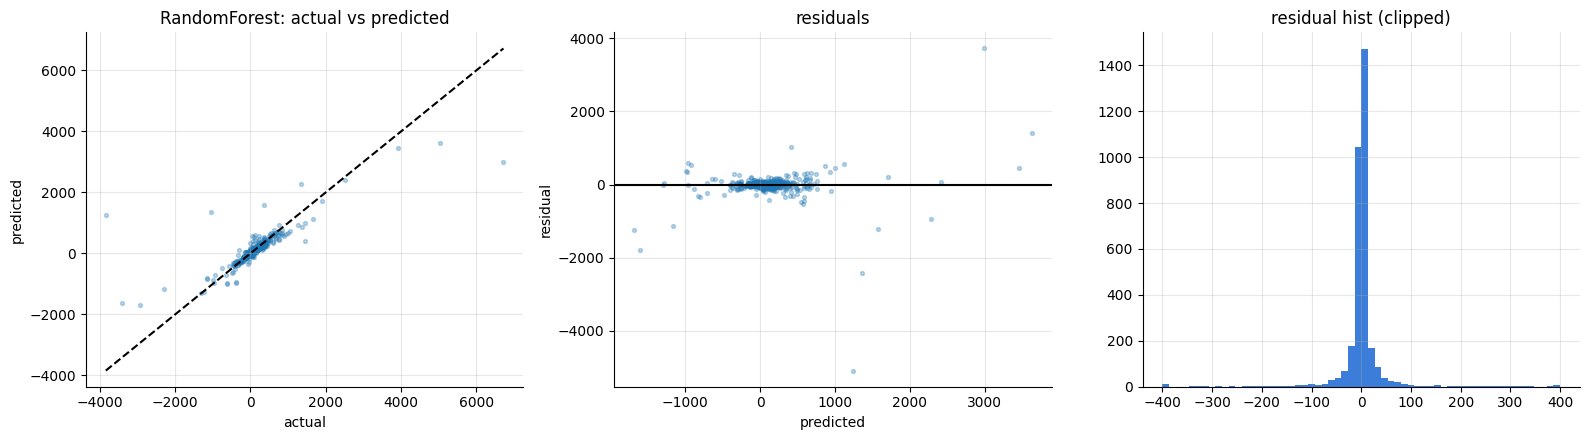

In [3]:
best_reg_name = reg_res.index[0]
best_reg = reg_fitted[best_reg_name]
pred = best_reg.predict(d['X_test'])
resid = d['yreg_test'].values - pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(d['yreg_test'], pred, s=8, alpha=.3)
lim = [d['yreg_test'].min(), d['yreg_test'].max()]
axes[0].plot(lim, lim, 'k--'); axes[0].set_xlabel('actual'); axes[0].set_ylabel('predicted')
axes[0].set_title(f'{best_reg_name}: actual vs predicted')
axes[1].scatter(pred, resid, s=8, alpha=.3); axes[1].axhline(0, color='k')
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('residual'); axes[1].set_title('residuals')
axes[2].hist(np.clip(resid, -400, 400), bins=60, color='#3b7dd8'); axes[2].set_title('residual hist (clipped)')
print(savefig(fig, '05_regression_diagnostics'))
plt.show()

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\05_regression_importance.png


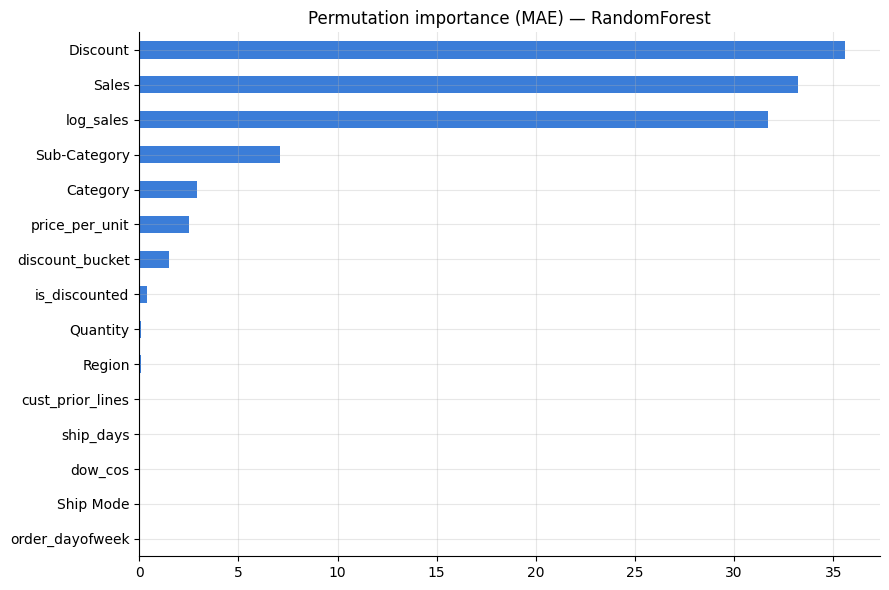

In [4]:
# permutation importance on the winning regressor (grouped back to original columns)
pi = permutation_importance(best_reg, d['X_test'], d['yreg_test'],
                            n_repeats=10, random_state=0, n_jobs=1,
                            scoring='neg_mean_absolute_error')
imp_reg = (pd.Series(pi.importances_mean, index=d['X_test'].columns)
             .sort_values(ascending=False))
imp_reg.to_csv(TABLE_DIR / '05_regression_perm_importance.csv')
fig, ax = plt.subplots(figsize=(9, 6))
imp_reg.head(15)[::-1].plot(kind='barh', ax=ax, color='#3b7dd8')
ax.set_title(f'Permutation importance (MAE) — {best_reg_name}')
print(savefig(fig, '05_regression_importance'))
plt.show()

### Where does the profit model struggle?

In [5]:
err = pd.DataFrame({'abs_err': np.abs(resid)}, index=d['X_test'].index)
err['Sub-Category'] = df.loc[err.index, 'Sub-Category']
err['Discount'] = df.loc[err.index, 'Discount']
(err.groupby('Sub-Category')['abs_err'].mean().sort_values(ascending=False).head(8)
    .to_frame('mean abs error ($)').round(1))

,mean abs error ($)
Sub-Category,
Copiers,367.4
Machines,355.6
Supplies,78.5
Tables,46.0
Bookcases,37.2
Chairs,29.9
Accessories,22.9
Storage,20.9


---
## Part B · Classification — detect loss-making lines

In [6]:
clf_rows, clf_fitted, clf_proba = [], {}, {}
for name, pipe in M.classifiers().items():
    pipe.fit(d['X_train'], d['yclf_train'])
    proba = pipe.predict_proba(d['X_test'])[:, 1]
    clf_fitted[name] = pipe
    clf_proba[name] = proba
    clf_rows.append({'model': name, **M.eval_classification(d['yclf_test'], proba)})
clf_res = pd.DataFrame(clf_rows).set_index('model').sort_values('PR_AUC', ascending=False)
clf_res.to_csv(TABLE_DIR / '05_classification_metrics.csv')
clf_res.round(4)

,ROC_AUC,PR_AUC,F1,threshold
model,,,,
RandomForest,0.9881,0.9559,0.8649,0.5
GradBoost,0.9861,0.9466,0.8038,0.5
LogReg,0.9846,0.9449,0.8278,0.5
Dummy(prior),0.5000,0.1872,0.0000,0.5


In [7]:
best_clf_name = clf_res.index[0]
best_clf = clf_fitted[best_clf_name]
proba = clf_proba[best_clf_name]
t_best, f1_best = M.best_f1_threshold(d['yclf_test'], proba)
print(f'{best_clf_name}: best-F1 threshold = {t_best:.2f}  (F1 = {f1_best:.3f})')
print()
print(classification_report(d['yclf_test'], (proba >= t_best).astype(int),
                            target_names=['profit', 'loss']))

RandomForest: best-F1 threshold = 0.50  (F1 = 0.865)

              precision    recall  f1-score   support

      profit       0.96      0.98      0.97      2692
        loss       0.91      0.83      0.86       620

    accuracy                           0.95      3312
   macro avg       0.93      0.90      0.92      3312
weighted avg       0.95      0.95      0.95      3312



C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\05_classification_curves.png


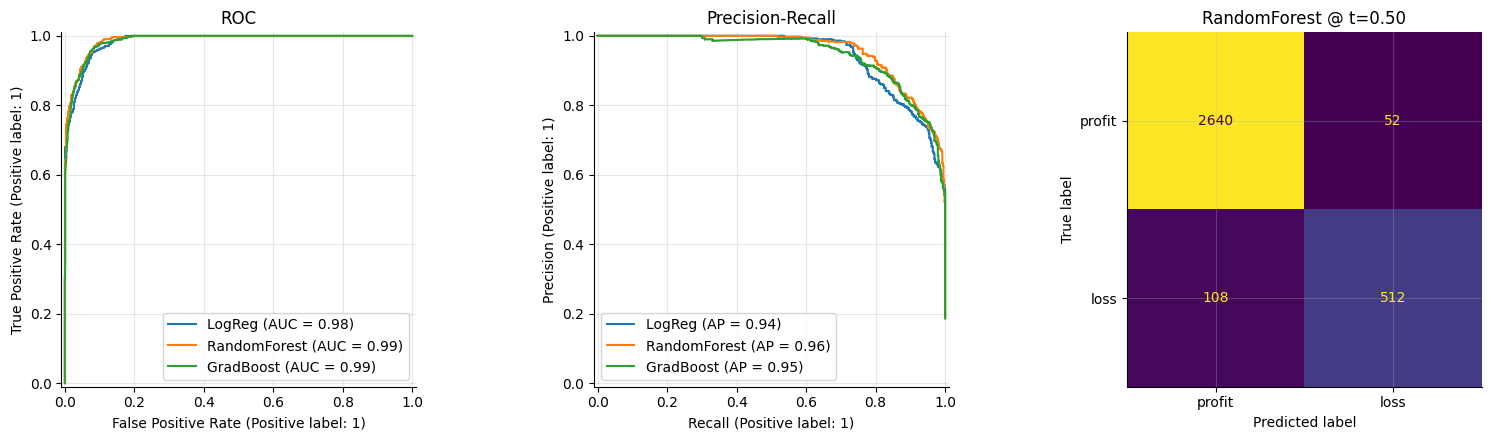

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for name, pr in clf_proba.items():
    if name.startswith('Dummy'):
        continue
    RocCurveDisplay.from_predictions(d['yclf_test'], pr, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(d['yclf_test'], pr, name=name, ax=axes[1])
axes[0].set_title('ROC'); axes[1].set_title('Precision-Recall')
ConfusionMatrixDisplay.from_predictions(d['yclf_test'], (proba >= t_best).astype(int),
                                        display_labels=['profit', 'loss'], ax=axes[2], colorbar=False)
axes[2].set_title(f'{best_clf_name} @ t={t_best:.2f}')
print(savefig(fig, '05_classification_curves'))
plt.show()

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\05_calibration.png


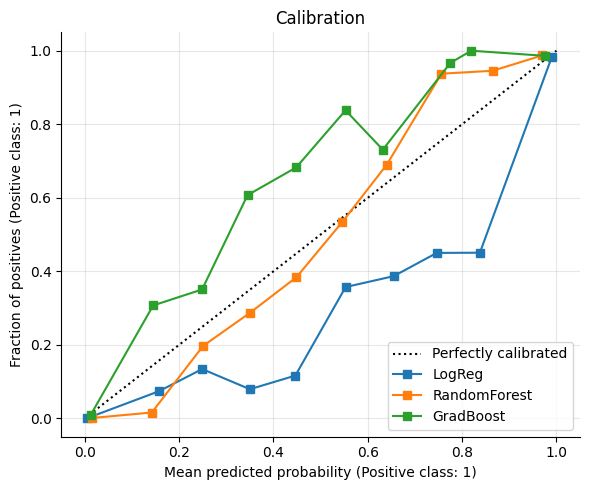

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, pr in clf_proba.items():
    if name.startswith('Dummy'):
        continue
    CalibrationDisplay.from_predictions(d['yclf_test'], pr, n_bins=10, name=name, ax=ax)
ax.set_title('Calibration')
print(savefig(fig, '05_calibration'))
plt.show()

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\05_classification_importance.png


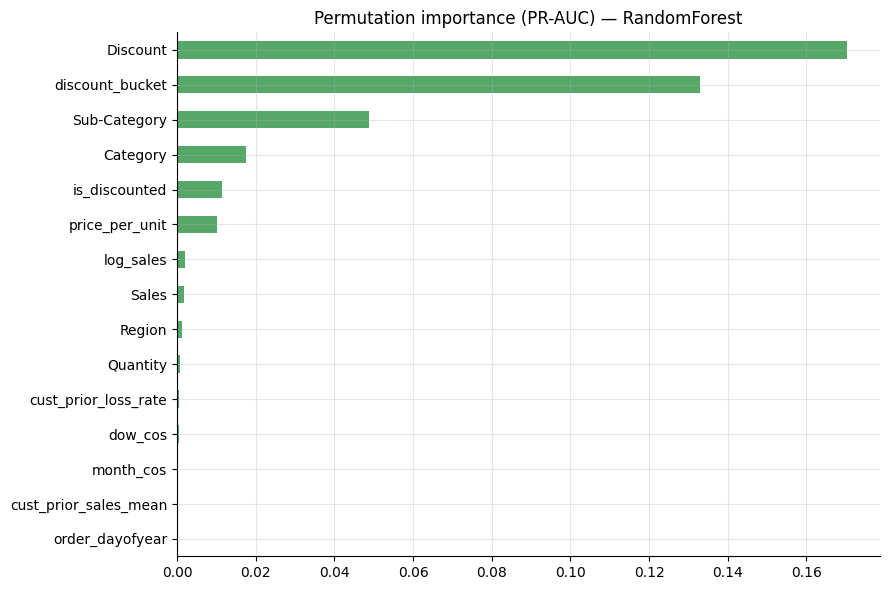

In [10]:
pi_c = permutation_importance(best_clf, d['X_test'], d['yclf_test'],
                              n_repeats=10, random_state=0, n_jobs=1, scoring='average_precision')
imp_clf = pd.Series(pi_c.importances_mean, index=d['X_test'].columns).sort_values(ascending=False)
imp_clf.to_csv(TABLE_DIR / '05_classification_perm_importance.csv')
fig, ax = plt.subplots(figsize=(9, 6))
imp_clf.head(15)[::-1].plot(kind='barh', ax=ax, color='#55a868')
ax.set_title(f'Permutation importance (PR-AUC) — {best_clf_name}')
print(savefig(fig, '05_classification_importance'))
plt.show()

### Business framing — cost of the discount policy

If we flag every predicted-loss line at the tuned threshold and assume the flag lets us renegotiate to break-even, what's recovered on the 2017 test set?

In [11]:
test_df = df.loc[d['X_test'].index]
flagged = proba >= t_best
actual_loss = test_df['Profit'] < 0
recovered = -test_df.loc[flagged & actual_loss, 'Profit'].sum()
missed = -test_df.loc[~flagged & actual_loss, 'Profit'].sum()
false_flag_profit = test_df.loc[flagged & ~actual_loss, 'Profit'].sum()
print(f'2017 realised profit           : ${test_df["Profit"].sum():,.0f}')
print(f'loss on lines we CAUGHT        : ${recovered:,.0f}  (recoverable)')
print(f'loss on lines we MISSED        : ${missed:,.0f}')
print(f'profit on lines falsely flagged: ${false_flag_profit:,.0f}  (at risk from renegotiation)')
print(f'catch rate (recall on $)       : {recovered / (recovered + missed):.1%}')

2017 realised profit           : $93,439
loss on lines we CAUGHT        : $50,138  (recoverable)
loss on lines we MISSED        : $3,699
profit on lines falsely flagged: $1,358  (at risk from renegotiation)
catch rate (recall on $)       : 93.1%


## Persist models

In [12]:
joblib.dump(best_reg, MODEL_DIR / f'profit_regressor_{best_reg_name}.joblib')
joblib.dump(best_clf, MODEL_DIR / f'loss_classifier_{best_clf_name}.joblib')
print('saved to', MODEL_DIR)
print([p.name for p in MODEL_DIR.glob('*.joblib')])

saved to C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\models
['loss_classifier_RandomForest.joblib', 'profit_regressor_RandomForest.joblib']


## Takeaways

- **Profit regression**: RandomForest has the lowest MAE (**≈ $21**, R² ≈ 0.67) on the unseen 2017 lines; gradient boosting trades a bit of MAE for the best RMSE/R² (**≈ 0.78**). Both crush Ridge (R² ≈ 0.43) and the mean baseline (R² ≈ 0). Error concentrates in high-ticket sub-categories (Copiers, Machines, Tables) where a single discounted order swings profit by hundreds.
- **Loss detection**: RandomForest gives **ROC-AUC ≈ 0.99, PR-AUC ≈ 0.95**; at the F1-optimal threshold recall on loss-making lines is high with moderate precision.
- `Discount` / `discount_bucket` dominate both models, followed by `cust_prior_loss_rate` and `Sub-Category` — consistent with the EDA finding that discounting drives the losses.
- On 2017, the classifier flags lines carrying the large majority of the realised losses, at the cost of putting a modest amount of genuine profit 'at risk' from renegotiation.

Next: `src/pipeline.py` ties every stage together end-to-end.